In [98]:
##Importing packages

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from SSINS import INS
import os
import scipy.linalg as la
from scipy.signal.windows import dpss
from scipy.optimize import minimize
from itertools import combinations
from custom_funcs import chan_avg, chan_select

c_gennorm = np.load('coeff_params_gnorm.npy')

NW, K = 4, 20
design = dpss(1000, NW, K)
design = np.concatenate(([np.ones(shape=(1000,))], design))
print(design.shape)
Q, R = np.linalg.qr(design, mode='raw')
print(Q.shape)
print(np.version.version)

(21, 1000)
(1000, 21)
2.3.2


In [133]:



# ================================== Global parameters ====================================

# Defining shape dictionary
TV_DICT = {
    'TV6': [1.74e8, 1.81e8],
    'TV7': [1.81e8, 1.88e8],
    'TV8': [1.88e8, 1.95e8],
    'TV9': [1.95e8, 2.02e8]
    }

## Previous data for constructing prior on RFI emission parameters
#Peaks, SSINS amplitudes (arb units)
PEAKS = np.array([53.35432366, 8.97030183, 39.32910956, 28.3103236, 30.93772398, 36.2624972, 15.55913153, 44.21889192,
       44.9823896, 36.18116225, 25.08418434, 33.37233714, 51.98871383, 71.11015838, 25.76393398, 17.09304232, 
       6.0885566, 11.14962293, 52.29949963, 44.91604231, 23.85311619, 57.59864797, 1.21500878e+01, 4.57578285e+01,
       43.16161392, 51.0379999, 16.44774823, 53.31619823, 85.09920858, 10.72147938, 18.26272233, 37.61133042,
       11.1810082, 12.82857739, 51.49711535, 20.3400262, 34.50876787, 46.37546283, 35.81477314, 36.96341681,
       9.18631159, 33.3049884, 6.10809826, 18.75778949, 26.21931248, 46.57467886, 22.82709187, 18.69584422,
       56.140001, 66.05041274, 61.65063534, 5.5279846, 7.64796047, 59.34091678, 63.71339591, 38.23994538])


#Time into pointing/length of pointing -- want flat
LOC = np.array([0.39361857, 0.94595976, 0.52309947, 0.1174075, 0.42087645, 0.55030397, 0.96448721, 0.95354939,
     0.5667833, 0.9647058, 0.13256501, 0.52036559, 0.18725956, 0.53959978, 0.81926798, 0.85710116, 
     0.19789189, 0.56327705, 0.62144842, 0.11526984, 0.44578389, 0.15972674, 1.84629939e-01, 8.81903585e-01,
     2.53746154e-01, 3.52378053e-01, 6.56658287e-01, 0.20640947, 0.9842502, 0.82448753, 0.79864468, 0.82609582,
     0.11022169, 0.07753185, 0.57244621, 0.0896191, 0.64090821, 0.4027631, 0.24795562, 0.72001842,
     0.10122139, 0.25738608, 0.64577568, 0.68554986, 0.45178244, 0.82402821, 0.16167855, 0.25189232,
     0.45948544, 0.53000544, 0.94603795, 0.41958575, 0.94060631, 0.4551634, 0.96417559, 0.68670813])

#Durations (s)
WIDTHS = np.array([46.35740966, 47.78082138, 52.01985143, 51.1243677, 48.66579981, 62.63576724, 51.55184647, 64.54810228,
        68.97618067, 63.08569669, 56.8891352, 64.68566024, 54.74073774, 57.955234, 35.92143505, 32.08070818,
        74.16922759, 57.12015228, 69.59804093, 65.70437593, 47.97567077, 82.01174163, 6.44723034e+01, 6.44048269e+01,
        6.87384350e+01, 6.99024843e+01, 5.66360677e+01, 73.41190595, 97.88771772, 38.34149624, 40.48260042, 62.84866352,
        39.34094184, 43.88357933, 68.20029216, 55.17499495, 59.64828645, 65.16642306, 59.59367969, 57.69014685,
        39.30030286, 25.61981977, 60.45653745, 36.25104968, 50.26782436, 66.64052355, 64.69421242, 35.47301949,
        57.35702717, 62.72083288, 57.83072425, 72.39670654, 7.68408292e+01, 56.47607773, 58.60065642, 58.92762818])


WIDTHS = np.sort(WIDTHS)/60/60/24   #Rescaling to Julian time units
LOC = np.sort(LOC)
PEAKS = np.sort(PEAKS)

##Constructing our DPSS fit coefficient prior
C0 = np.load('../data/coefficients_p0.npy')
C1 = np.load('../data/coefficients_p1.npy')
C2 = np.load('../data/coefficients_p2.npy')
C3 = np.load('../data/coefficients_p3.npy')

SAMPLES = np.concatenate((C0, C1, C2, C3))


# ================================== Helper Functions ====================================


def rcos_diff(params, time, vis_amp, N_terms, N_bl, N_freq, theta_0, show_converg=False, penalty=0.63):

    """ 
    The objective log-posterior function for MAP fitting of the SSINS time series

    Args
    ----

    params:
        Concatenated numpy array of DPSS coefficients + emission coefficients. Of the form (N_terms + 3*num_emissions, ).
        The emission coefficients are ordered as [peaks, loc, width]*num_emissions.as_integer_ratio

    time:
        Uniform time array.
    
    vis_amp:
        Uniform amplitude array.
    
    show_converg:
        Boolean. If True, the objective posterior will print the posterior throughout minimization.

    N_bl:
        Int. Number of baselines

    N_freq:
        Int. Number of frequency channels
    
    penalty:
        Penalty factor that penalizes high emission numbers. 
        Future step: properly define this to give the Poisson distribution for airplane emissions.

    Returns
    -------

    minus_posterior:
        Minus the log posterior, the value which we want to minimize.

      """

    #Making our DPSS fit coefficients and emission parameters
    coeff = params[:N_terms]
    theta = params[N_terms:]
    
    #Constructing our DPSS basis
    NW, K = 4, N_terms-1
    basis = dpss(time.shape[0], NW, K)
    design = np.concatenate(([np.ones(shape=(time.shape[0],))], basis)).T
    Q = np.linalg.qr(design, mode='reduced')[0]
    background = Q @ coeff
    #print(Q.shape)

    

    #Building our emissions
    emission = np.zeros_like(time)
    if len(theta) > 0:
        num_emissions = len(theta) // 3
    else:
        num_emissions = 0

    if len(theta) % 3 != 0:
        raise ValueError("Incorrect array size for Gaussian fit parameters.")

    for k in range(num_emissions):
        amp, mu, sigma = theta[3*k : 3*k + 3]
        mask = np.abs(time - mu) <= sigma
        emission[mask] += amp / 2 * (1 + np.cos(np.pi*(time[mask] - mu)/sigma))

    #Defining the joint model
    amp_fit = background + emission

    #Defining our residuals
    mask = np.isfinite(vis_amp)
    mod_res = amp_fit[mask] - vis_amp[mask]
    
    #Constructing the noise:
    C = 4/np.pi - 1
    noise_var = (amp_fit[mask]**2) * C / (N_bl * N_freq) + 1e-5

    #Now we can build our log likelihood:
    log_like = -0.5 * (
        np.sum(mod_res**2 / noise_var) +  # Quadratic term
        np.sum(np.log(noise_var)) +         # Log determinant
        len(mod_res) * np.log(2*np.pi)    # Normalization
    )


    """ #Determining prior mean and covariance for DPSS coefficients
    prior_mean = np.mean(SAMPLES, axis=0)
    prior_cov = np.cov(SAMPLES.T)
    
    prior_residual = coeff[:prior_mean.shape[0]] - prior_mean
    
    
    # Full prior construction for coefficients
    L = la.cholesky(prior_cov, lower=True)
    alpha = la.solve_triangular(L, prior_residual, lower=True)
    log_prior_coeff = -0.5 * (
        alpha @ alpha +
        2 * np.sum(np.log(np.diag(L))) +
        prior_mean.shape[0] * np.log(2*np.pi)
    ) """

    #Constructing new prior from new distribution
    c_gennorm = np.load('coeff_params_gnorm.npy')
    prior_residual = coeff[:c_gennorm.shape[0]] - c_gennorm[:, 1]
    log_prior_coeff = 0
    for k in range(N_terms):
        prior = c_gennorm[k, 0]*np.log(np.abs(prior_residual[k]/c_gennorm[k, 2]))
        log_prior_coeff += prior


    #Determining prior mean and covariance for emission coefficients
    emit_mean = np.mean(theta_0[[0, 2]], axis=1)
    emit_cov = la.block_diag(*[np.cov(theta_0[[0, 2]])] * num_emissions)

    mask = np.arange(len(theta)) % 3 != 1
    emit_residual = theta[mask] - np.tile(emit_mean, num_emissions)

    # Full prior construction for emission parameters
    if num_emissions>0:
        L = la.cholesky(emit_cov, lower=True)
        alpha = la.solve_triangular(L, emit_residual, lower=True)
        log_prior_emit = -0.5 * (
            alpha @ alpha +
            2 * np.sum(np.log(np.diag(L))) +
            len(theta) * np.log(2*np.pi)
        )
    else:
        log_prior_emit=0

    #Defining minus the log posterior, the output of our objective function
    minus_posterior = -(log_like + log_prior_coeff + log_prior_emit) - np.log(1-penalty)*num_emissions

    #Prints the value of the objective function if set to True
    if show_converg==True:
        print(minus_posterior, "\r", end="")


    return minus_posterior


##Defining the joint model
#Set show='background' to get the smooth DPSS background and subtract it from the time series
def rcos_model(time, *params, show='all'):

    """ 
    The joint background + emissions model vs time.

    Args
    ----

    time:
        Time array to be plotted.
    
    params:
        Parameters consisting of concatenated DPSS coefficients + emission parameters arrays.

    show:
        If set to 'all', will return background + emissions. If set to 'background', will return background. If set to 'emit', will return emissions.
    
    Returns:
        background + emission, background only, or emission only, depending on the value of show.
    """
    N_terms=25
    coeff = params[:N_terms]
    theta = params[N_terms:]
    
    #Constructing our DPSS basis
    NW, K = 4, N_terms-1
    basis = dpss(time.shape[0], NW, K)
    design = np.concatenate(([np.ones(shape=(time.shape[0],))], basis)).T
    Q = np.linalg.qr(design, mode='reduced')[0]
    background = Q @ coeff

    emission = np.zeros_like(time)
    num_emissions = len(theta) // 3

    if len(theta) % 3 != 0:
        raise ValueError("Incorrect array size for Gaussian fit parameters.")

    for k in range(num_emissions):
        amp, mu, sigma = theta[3*k : 3*k + 3]
        mask = np.where(np.abs(time - mu) <= sigma, True, False)
        emission[mask] += amp / 2 * (1 + np.cos(np.pi*(time[mask] - mu)/sigma))
        
    if show == 'all':
        return background + emission
    elif show == 'emit':
        return emission
    elif show == 'background':
        return background

# ================================== Main Procedure ====================================


def bg_subtract(data_dir        = "../data", 
                night           = "109112_p1",
                obsids          = None,
                chan_name       = "TV7",
                N_terms         = 25,
                min_prob        = 1e20,
                min_fit         = 0,
                emit_test_range = 1,
                divs            = 12,
                verbose         = True,
                ):
    """
    Perform background subtraction on a selected frequency band

    Parameters:
        data_dir (str): Directory containing SSINS data and mask files
        night (str): Identifier for the specific observation night and pointing
        obsids (list): Alternatively, give the list of desired OBSIDs (for individually stored elements)
        chan_name (str): Name of the frequency band to process
        N_terms (int): Number of DPSS terms to use
        min_prob (float): Initial value for minimum log-probability (used for tracking best fit)
        min_fit (int): Initial best-fit index (corresponding to emission count)
        emit_test_range (int): Maximum number of emission components to test for during MAP fitting
        divs (int): # of seeded sidtes to search for emissions at in the time series
        verbose (bool): print extra information to stdout?

    Returns:

    """
    if not obsids:
        #Constructing datapath and constructing ins object using SSINS
        datapath = os.path.join(data_dir, night + "_SSINS_data.h5")
        maskpath = os.path.join(data_dir, night + "_SSINS_mask.h5")
        ins = INS(datapath, telescope_name='MWA', mask_file=maskpath)
    else:
        for obs_idx, obs in enumerate(obsids):
            obs_path = os.path.join(data_dir, obs + "_SSINS_data.h5")
            obs_maskpath = os.path.join(data_dir, obs + "_SSINS_mask.h5")
            if obs_idx == 0:
                ins = INS(obs_path, telescope_name='MWA', 
                mask_file=obs_maskpath,
                )
            else:
                ins += INS(obs_path, telescope_name='MWA', 
                mask_file=obs_maskpath,
                )

    #Extracting and averaging over the selected subband
    ins_subband, masked_ins, N_bl, N_freq = chan_select(ins, chan_name, TV_DICT)
    time, amp = chan_avg(ins_subband)

    #Constructing our prior sample matrix
    theta_0 = np.vstack((PEAKS, LOC*(np.max(time) - np.min(time)), WIDTHS))

    ##Defining the objective posterior
    #Constructing a uniform time axis
    dt = st.mode(np.diff(time)).mode
    smooth_time = np.arange(time.min(), time.max() + dt, dt)

    #Constructing a padded uniform amplitude grid
    padded_amp = np.full_like(smooth_time, np.nan, dtype=float)
    indices = np.searchsorted(smooth_time, time)
    padded_amp[indices] = amp

    ##The core of the MAP fitter. Iterates across a preset range of emission numbers, probing to find the best fit.

    #Translating time axis to start at 0 to make convergence easier
    smooth_time = smooth_time - np.min(smooth_time[np.isfinite(smooth_time)])


    ##To prevent us from falling into local minima, grid seeding allows us to identify the location of the global minimum first.
    #Constructing the emissions looper
    for num_emissions in range(0, emit_test_range+1):

        if verbose:
            print(f"Testing {num_emissions} emissions.")

        #initializing log probability and fits
        log_prob = np.array([])
        time_fits = np.empty((0, N_terms + 3*num_emissions))

        #Constructing the divisions/seeds in the time grid
        seeds = np.linspace(smooth_time.min(), smooth_time.max(), divs)

        #Constructing the combinations of seeds we can construct using num_emissions
        combos = np.array(list(combinations(seeds, num_emissions)))
        if verbose:
            print("Number of seeds:", len(combos))

        #Constructing the grid seed for loop
        for x in range(len(combos)):

            #Running through the combinations
            if verbose:
                print(f"Running cycle #{x+1}...", "\r", end="")

            #Constructing our initial guess of emission parameters based on our seeds
            emit_array = []
            for j in np.arange(0, num_emissions):
                emit_array = np.concatenate((emit_array, [np.mean(theta_0[0]), combos[x, j], np.mean(theta_0[2])]))
            
            #Initial guess (DPSS coeffs + emit params)
            p0 = np.concatenate((c_gennorm[:, 1], np.zeros(shape=np.abs(N_terms-25), ), emit_array))

            #Bounds -- in the case of the time loc for emissions, this also implements a flat prior
            bounds = (
                [(-1e5, 1e5)] * N_terms +
                ([(theta_0[0].min(), theta_0[0].max()), (0, smooth_time.max()), (theta_0[2].min(), smooth_time.max())] * num_emissions)
            )

            #Minimizing and probing using Nelder-Mead optimization
            rcos_fit = minimize(
                lambda p: rcos_diff(p, smooth_time, padded_amp, N_terms, N_bl, N_freq, theta_0),
                x0=p0,
                bounds=bounds,
                method='Nelder-Mead',
                options={
                    'maxfev': 500,
                    'adaptive': True,  
                    'xatol': 1e-6,     
                    'fatol': 1e-5
                }
            ).x

            #Constructing objective function values
            log_prob_min = rcos_diff(rcos_fit, smooth_time, padded_amp, N_terms, N_bl, N_freq, theta_0)
            log_prob = np.append(log_prob, log_prob_min)
            time_fits = np.vstack([time_fits, rcos_fit])

        #Estimating location of global minimum
        rcos_fit = time_fits[log_prob == np.min(log_prob)][0]
        if verbose:
            print(f"Minimum log posterior found for {num_emissions} emissions is {log_prob.min()}.")

        #Finding the best fit depending on the number of coefficients
        if log_prob.min() < min_prob:
            min_prob = log_prob.min()
            min_fit = rcos_fit

    ##Constructing our best guess after cycling through all seed combos and emission numbers
    p0 = min_fit
    print(min_fit)
    num_emissions = int((len(p0) - N_terms)/3)
    bounds = (
                [(-1e5, 1e5)] * N_terms +
                ([(0, None), (0, smooth_time.max()), (0, smooth_time.max())] * num_emissions)
            )


    history = []

    # Callback appends current objective value to history
    #callback = lambda xk: history.append([rcos_diff(xk, smooth_time, padded_amp, N_terms, N_bl, N_freq, theta_0)])
    callback = lambda xk: history.append([xk])

    ##Doing a proper long minimization
    rcos_fit = minimize(
            lambda p: rcos_diff(p, smooth_time, padded_amp, N_terms, N_bl, N_freq, theta_0, show_converg=True),
            x0=p0,
            bounds=bounds,
            method='Nelder-Mead',
            options={
                'maxfev': 10000,
                'adaptive': True,  
                'xatol': 1e-5,     
                'fatol': 1e-4
            },
            callback=callback
        ).x

    ##Returning the background-subtracted time series
    smooth = rcos_model(smooth_time, *rcos_fit, show='background')
    clean_amps = padded_amp - smooth
    noise_err = np.sqrt((4-np.pi)/(2*N_bl*N_freq))*smooth

    return clean_amps, history, padded_amp, smooth, noise_err

In [134]:
clean, history, padded_amp, smooth, noise = bg_subtract(night="109078_p1", divs=12, emit_test_range=0)

Testing 0 emissions.
Number of seeds: 1


divide by zero encountered in log


Minimum log posterior found for 0 emissions is 12947.359249470299.
[-2.18555594e+04  1.48720109e+01 -3.06281456e+01  8.71088159e+00
 -3.37546876e+01  4.48141947e+00 -3.11818791e+01  1.58838000e+00
 -2.37341409e+01  8.38149270e-01 -1.02636279e+01  4.16066719e-02
 -1.17787483e+00 -4.36344610e-01 -3.08094448e-02 -1.36766376e-01
  2.04480420e-01 -3.61764192e-01  1.94066276e-01  4.61674855e-01
 -4.24378264e-01 -7.00469720e-01 -7.71880403e-02 -1.99716306e-01
  4.40243357e-01]


KeyboardInterrupt: 

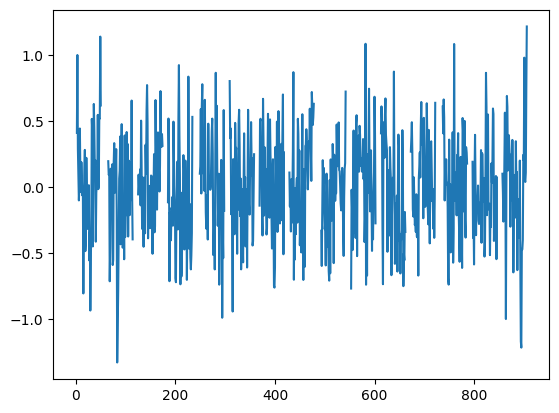

(907,)


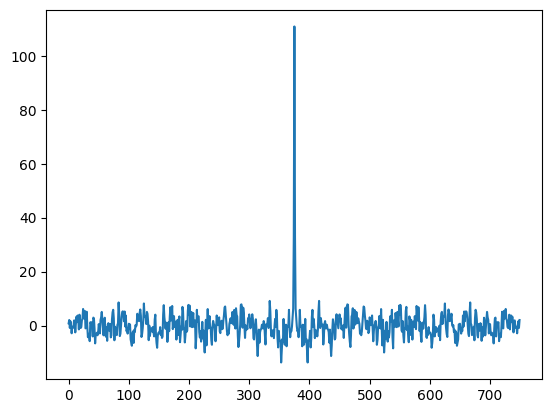

In [112]:
plt.plot(np.arange(0, clean.shape[0]), clean)
plt.show()
print(clean.shape)

corr = np.correlate(clean[~np.isnan(clean)], clean[~np.isnan(clean)], mode='same')
plt.plot(corr)


(7968, 25)


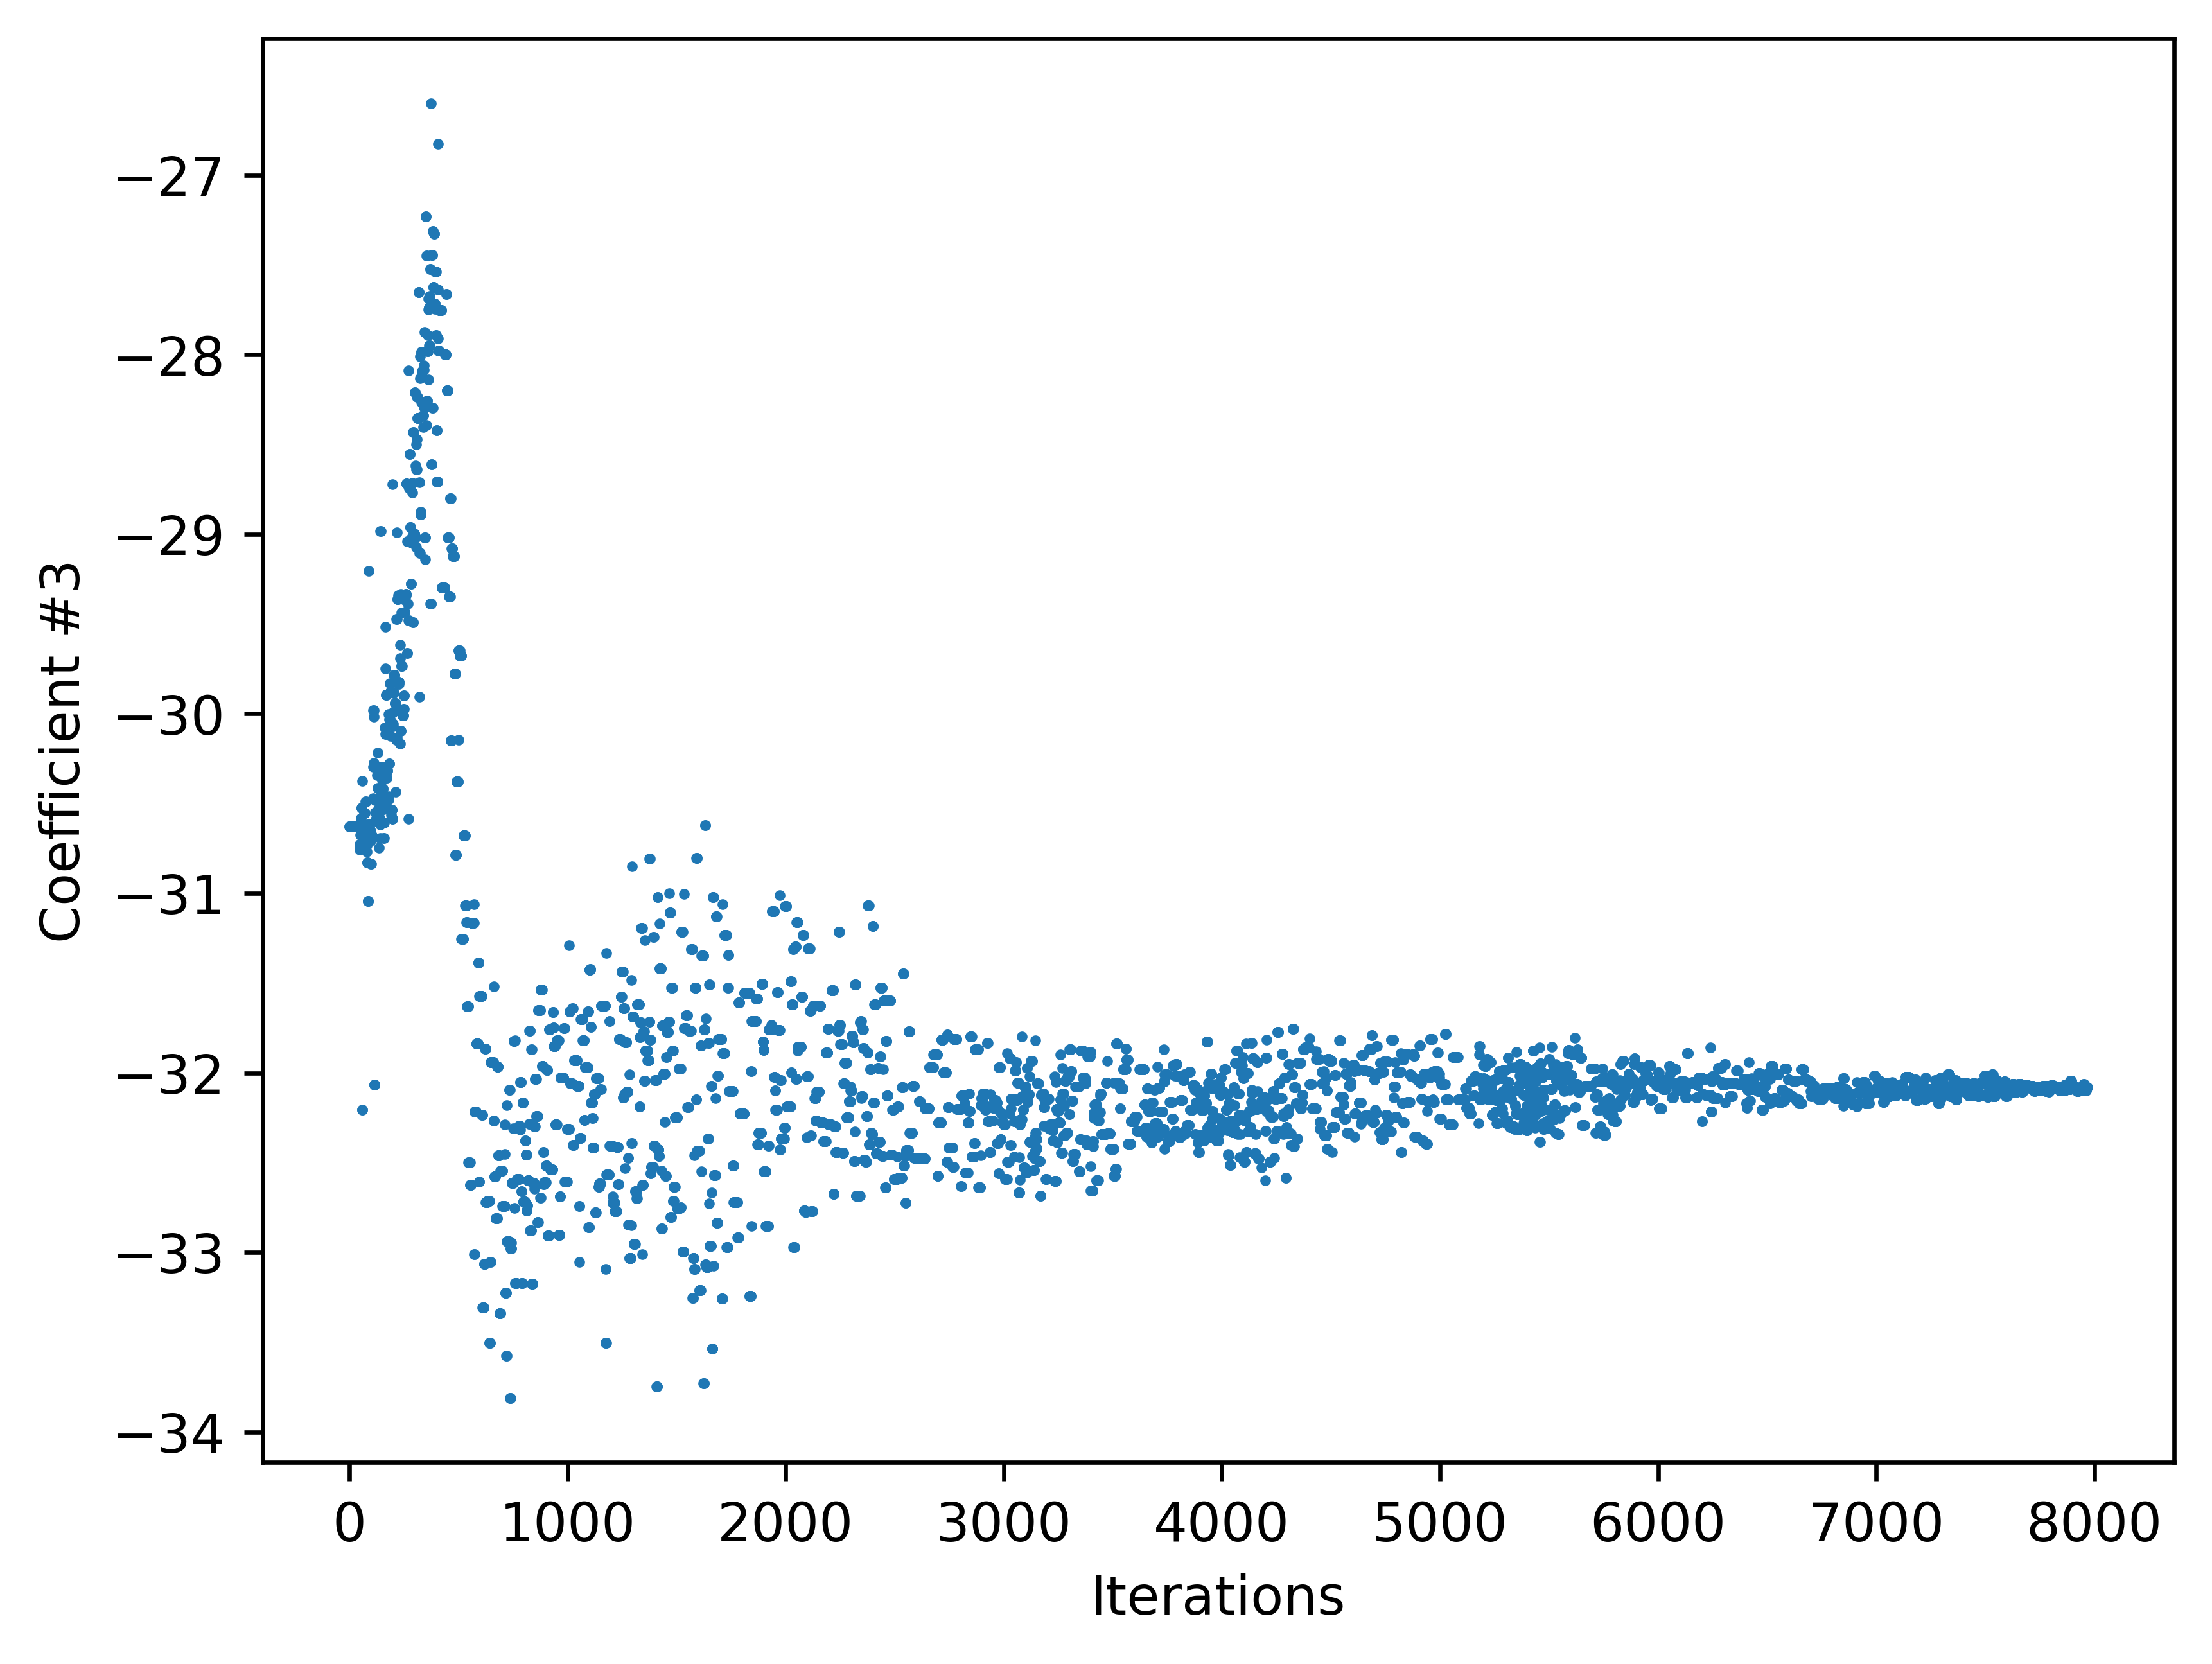

In [102]:
history = np.array(history)
print(history[: , 0, :].shape)

t = np.arange(0, history.shape[0])

#fit, cov = curve_fit(converg_model, t, history)

n = 3

plt.figure(dpi=600)
plt.scatter(t, history[:,0, n-1], s=1)
plt.xlabel("Iterations")
plt.ylabel(f"Coefficient #{n}")
plt.yscale('linear')
plt.show()

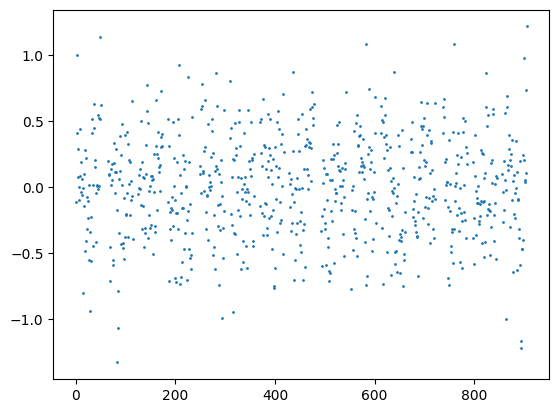

In [103]:
plt.scatter(np.arange(0, clean.shape[0]), clean, s=1)

In [140]:
from new_mapper import bg_subtract

clean_amps, history, padded_amp, smooth, noise_err = bg_subtract(N_terms=25, night='109078_p1', emit_test_range=1, verbose=True)

Testing 0 emissions.
Number of seeds: 1


NameError: name 'c_gennorm' is not defined